In [5]:
import numpy as np

def clean_outliers(array: np.ndarray) -> np.ndarray:
    array = array.astype(np.float64)
    var = round(array.mean()+(2*np.std(array)), 2)
    array[array > var] = np.median(array) 
    return array

clean_outliers(np.array([50, 60, 250, 55, 70, 5]))    


array([50. , 60. , 57.5, 55. , 70. ,  5. ])

In [16]:
# Problem 2
import numpy as np

def normalize_image(image: np.ndarray) -> float:
    # img1 = image[0:4,0:4]
    # img2 = image[4:8,0:4]
    # img3 = image[8:12,0:4]
    # img4 = image[12:16,0:4]
    # print(image)
    normalized_image = np.zeros_like(image, dtype=float)
    skip = 4
    i = 0
    j = 0
    while j < 16:
        i = 0
        while i < 16:
            block = image[i:i+skip,j:j+skip]            
            _mean = np.mean(block)
            # print(image[i:i+skip, j:j+skip], _mean)
            # print(i,i+skip,",", j,j+skip, " M:", _mean)
            n_block = block - _mean
            normalized_image[i:i+skip,j:j+skip] = n_block
            i += skip
        j += skip
    # print(image)   
    # _mean = np.mean(image[:,:])
    # image = image - _mean    
    return round(np.std(normalized_image),3)

np.random.seed(5)
print(round(normalize_image(np.arange(256).reshape(16,16)),3)) 

17.923


In [12]:
# Problem 2 - another attempt
import numpy as np

def normalize_image(image: np.ndarray) -> float:
    normalized_image = np.zeros_like(image, dtype=float)
    for r in range(0, 16, 4):
        for c in range(0, 16, 4):
            # Extract the 4x4 block
            block = image[r:r+4, c:c+4]

            # Compute the mean of the block
            block_mean = np.mean(block)

            # Normalize the block by subtracting its mean
            normalized_block = block - block_mean

            # Place the normalized block back into the normalized_image array
            normalized_image[r:r+4, c:c+4] = normalized_block

    return np.std(normalized_image)
        
np.random.seed(5)
print(round(normalize_image(np.arange(256).reshape(16,16)),3))
#print(round(normalize_image(np.array([[10,20,30,40],[15,25,35,45],[20,30,40,50],[25,35,45,55]])),3))


17.923


In [ ]:
np.arange(5)

array([0, 1, 2, 3, 4])

In [55]:
import random

random.randint(1,5)

4

In [36]:
# Problem 3
import numpy as np
def pairwise_distance(A: np.ndarray, B: np.ndarray) -> float:
    '''
    Compute average pairwise Euclidean distance between points in A and B.
    '''
    lookedup = []
    distance = []
    for a,b in A:
        for p,q in B:
            if not (str(a)+str(b)+str(p)+str(q) in lookedup or str(p)+str(q)+str(a)+str(b) in lookedup):
                distance.append(np.sqrt(np.power(a-p, 2) + np.power(b-q, 2)))
                lookedup.append(str(a)+str(b)+str(p)+str(q))
                lookedup.append(str(p)+str(q)+str(a)+str(b))

    print(lookedup)
    print(distance)
    return np.mean(distance)                

print(round(pairwise_distance(np.array([[0,0],[1,1]]), np.array([[2,2],[3,3]])),3))

['0022', '2200', '0033', '3300', '1122', '2211', '1133', '3311']
[np.float64(2.8284271247461903), np.float64(4.242640687119285), np.float64(1.4142135623730951), np.float64(2.8284271247461903)]
2.828


In [68]:
# Problem 4
import numpy as np
import pandas as pd
def get_daily_top_product(df: pd.DataFrame) -> list:
    '''
    Return list of products with maximum daily sales value.
    '''
    df['OrderDate'] = pd.to_datetime(df['OrderDate'])
    df['Revenue'] = df['Price'] * df['Quantity']

    newl = df.groupby("OrderDate")["Revenue"].nlargest(1)
    
    top_n = (
        df.groupby("OrderDate", group_keys=False, sort=True)[["OrderDate", "Revenue", "Product"]]
        .apply(lambda g: g.nlargest(1, 'Revenue'), include_groups=False)
        .reset_index(drop=True)
    )

    return top_n["Product"].to_list()

data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108],
    'OrderDate': ['2025-10-01', '2025-10-01', '2025-10-02',
                  '2025-10-02', '2025-10-03', '2025-10-04',
                  '2025-10-04', '2025-10-05'],
    'Product': ['Laptop', 'Mouse', 'Keyboard', 'Laptop', 'Monitor',
                'Mouse', 'Webcam', 'Keyboard'],
    'Category': ['Electronics', 'Peripherals', 'Peripherals',
                 'Electronics', 'Electronics', 'Peripherals',
                 'Peripherals', 'Peripherals'],
    'Price': [1200, 25, 75, 1250, 300, 30, 50, 80],
    'Quantity': [2, 5, 3, 1, 2, 4, 1, 2]
}
example_df = pd.DataFrame(data)
example_df['OrderDate'] = pd.to_datetime(example_df['OrderDate'])

print(get_daily_top_product(example_df)) 

['Laptop', 'Laptop', 'Monitor', 'Mouse', 'Keyboard']


In [59]:
# Problem 5
import pandas as pd
from itertools import combinations
from collections import Counter

def frequent_product_pair_(df: pd.DataFrame) -> tuple:
    '''
    Return product pair that appears most frequently together in same order.
    '''
    df["NextProduct"] = df.groupby(["OrderID"])["Product"].shift(-1)
    df_pairs = df.dropna(subset=["NextProduct"])
    product_pairs = df_pairs.apply(lambda row: tuple(sorted([row['Product'], row['NextProduct']])), axis=1)
    product_pairs.sort_values(inplace=True)
    print(product_pairs)
    frequent_pair = product_pairs.value_counts().head(1)
    return tuple(sorted(frequent_pair.index[0]))

def frequent_product_pair(df: pd.DataFrame) -> tuple:
    '''
    Return product pair that appears most frequently together in same order.
    '''
    pairs_per_order = df.groupby('OrderID')['Product'] \
        .apply(lambda row: [tuple(sorted(pair)) for pair in (combinations(row, 2))])
    # print(pairs_per_order)

    # 2. Convert the Series of lists into a single flat Series of tuples.
    flat_pairs_series = pairs_per_order.sort_values().explode()
    # print(flat_pairs_series)

    # 3. Count the frequency of each pair and get the top 1.
    max_count = flat_pairs_series.value_counts().max('index')
    # print(max_count)
    most_frequent_pair_series = flat_pairs_series.value_counts()

    most_frequent_pair_series = most_frequent_pair_series[most_frequent_pair_series==max_count]
    most_frequent_pair_series.sort_index(inplace=True)
    print(most_frequent_pair_series)

    # 4. Convert the result into the requested tuple format
    return most_frequent_pair_series.head(1).index[0]


data = {
    'OrderID': [101, 101, 101, 105, 105, 105, 107, 107, 107],
    'OrderDate': ['2025-10-01', '2025-10-01', '2025-10-02',
                  '2025-10-02', '2025-10-03', '2025-10-04',
                  '2025-10-04', '2025-10-05', '2025-10-05'],
    'Product': ['Mouse', 'Monitor', 'Keyboard', 'Laptop', 'Monitor',
                'Mouse', 'Laptop', 'Keyboard', 'Monitor'],
    'Category': ['Electronics', 'Peripherals', 'Peripherals',
                 'Electronics', 'Electronics', 'Peripherals',
                 'Peripherals', 'Peripherals', 'Peripherals'],
    'Price': [1200, 25, 75, 1250, 300, 30, 50, 80, 75],
    'Quantity': [2, 5, 3, 1, 2, 4, 1, 2, 1]
}
df_full = pd.DataFrame(data)
df_full['OrderDate'] = pd.to_datetime(df_full['OrderDate'])
#print(df_full)
print(frequent_product_pair(df_full))

Product
(Keyboard, Monitor)    2
(Laptop, Monitor)      2
(Monitor, Mouse)       2
Name: count, dtype: int64
('Keyboard', 'Monitor')


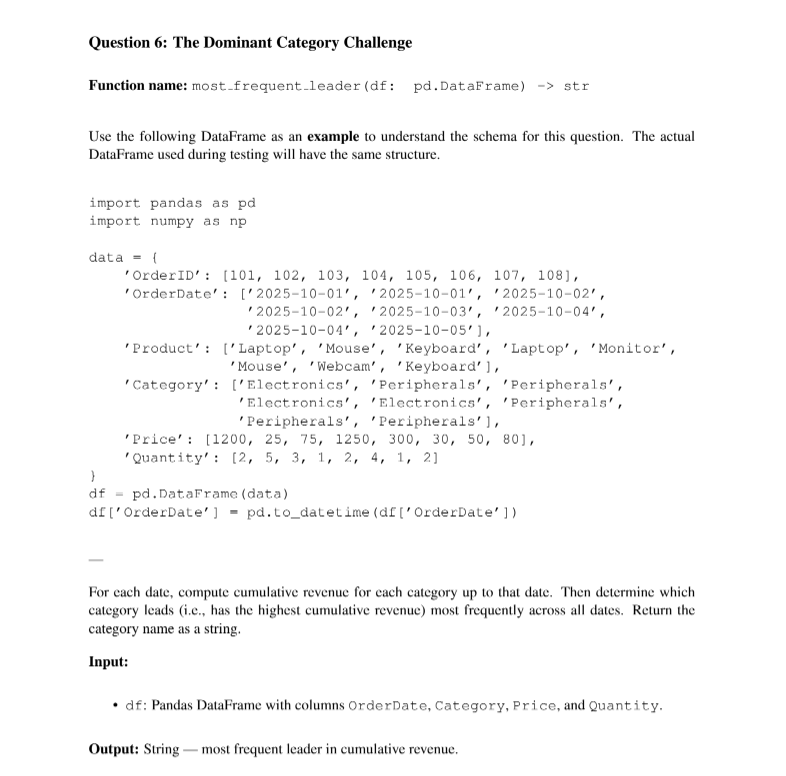

In [ ]:
import pandas as pd
def most_frequent_leader(df: pd.DataFrame) -> str:
    '''
    Identify category that was top-selling on most days based on cumulative revenue.
    '''
 
    df['Revenue'] = df['Price'] * df['Quantity']

    daily_revenue = df.groupby(['OrderDate', 'Category'])['Revenue'].sum().reset_index()

    daily_revenue['CumulativeRevenue'] = daily_revenue.groupby('Category')['Revenue'].cumsum()
    #print(daily_revenue)

    daily_revenue_sorted = daily_revenue.sort_values(
        by=['OrderDate', 'CumulativeRevenue'], 
        ascending=[True, False]
    )
    # print(daily_revenue_sorted)
    daily_leaders = daily_revenue_sorted.drop_duplicates(
        subset=['OrderDate'], 
        keep='first'
    )
    
    leader_counts = daily_leaders['Category'].value_counts()

    if leader_counts.empty:
        return "" # Handle case of empty DataFrame
        
    return leader_counts.index[0]

data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108],
    'OrderDate': ['2025-10-01', '2025-10-01', '2025-10-02',
                  '2025-10-02', '2025-10-03', '2025-10-04',
                  '2025-10-04', '2025-10-05'],
    'Product': ['Laptop', 'Mouse', 'Keyboard', 'Laptop', 'Monitor',
                'Mouse', 'Webcam', 'Keyboard'],
    'Category': ['Electronics', 'Peripherals', 'Peripherals',
                 'Electronics', 'Electronics', 'Peripherals',
                 'Peripherals', 'Peripherals'],
    'Price': [1200, 25, 75, 1250, 300, 30, 50, 80],
    'Quantity': [2, 5, 3, 1, 2, 4, 1, 2]
}
df = pd.DataFrame(data)
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

print(most_frequent_leader(df))


   OrderDate     Category  Revenue  CumulativeRevenue
0 2025-10-01  Electronics     2400               2400
1 2025-10-01  Peripherals      125                125
2 2025-10-02  Electronics     1250               3650
3 2025-10-02  Peripherals      225                350
4 2025-10-03  Electronics      600               4250
5 2025-10-04  Peripherals      170                520
6 2025-10-05  Peripherals      160                680
Electronics


Question 7: The Sales Simulation
Function name: simulate sales(sales df: pd.DataFrame, days: int = 30) ->
list

Simulate sales data for the next days (default = 30).
For each day, generate:
• A price = last known price + random noise from Normal(0, 5)
• A quantity = random integer between 1 and 5
Return a list of tuples, where each tuple represents one simulated sale: (price, quantity) for
each simulated day.

In [2]:
import pandas as pd
import numpy as np
np.random.seed(0)
def simulate_sales(sales_df: pd.DataFrame, days = 30) -> list:
    l = []
    sales_df.sort_values("OrderDate", inplace=True, ascending=False)
    x = sales_df["Price"].iloc[0]

    print("Base price", x)
    for _ in range(days):
        x += np.random.normal(0,5)
        l.append((x,np.random.randint(1,6)))
    return l

data = {
    'OrderID': [101, 102, 103],
    'OrderDate': ['2025-10-01', '2025-10-02', '2025-10-03'],
    'Price': [100, 105, 110]
}
df = pd.DataFrame(data)

simulate_sales(df, 1)

Base price 110


[(np.float64(118.82026172983832), 4)]

In [94]:
import pandas as pd
import numpy as np
data = {
'OrderID': [101, 102, 103, 104, 105, 106, 107, 108],
'OrderDate': ['2025-10-01', '2025-10-01', '2025-10-02',
'2025-10-02', '2025-10-03', '2025-10-04',
'2025-10-04', '2025-10-05'],

'Product': ['Laptop', 'Mouse', 'Keyboard', 'Laptop', 'Monitor',

'Mouse', 'Webcam', 'Keyboard'],

'Category': ['Electronics', 'Peripherals', 'Peripherals',
'Electronics', 'Electronics', 'Peripherals',
'Peripherals', 'Peripherals'],
'Price': [1200, 25, 75, 1250, 300, 30, 50, 80],
'Quantity': [2, 5, 3, 1, 2, 4, 1, 2]
}
df = pd.DataFrame(data)
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [95]:
df['Revenue'] = df['Price'] * df['Quantity']
df

,OrderID,OrderDate,Product,Category,Price,Quantity,Revenue
0,101,2025-10-01,Laptop,Electronics,1200,2,2400
1,102,2025-10-01,Mouse,Peripherals,25,5,125
2,103,2025-10-02,Keyboard,Peripherals,75,3,225
3,104,2025-10-02,Laptop,Electronics,1250,1,1250
4,105,2025-10-03,Monitor,Electronics,300,2,600
5,106,2025-10-04,Mouse,Peripherals,30,4,120
6,107,2025-10-04,Webcam,Peripherals,50,1,50
7,108,2025-10-05,Keyboard,Peripherals,80,2,160


In [96]:
idx_max_revenue = df.groupby('OrderDate')['Revenue'].idxmax()
print(idx_max_revenue)

OrderDate
2025-10-01    0
2025-10-02    3
2025-10-03    4
2025-10-04    5
2025-10-05    7
Name: Revenue, dtype: int64


In [97]:
max_revenue_per_date = df.loc[idx_max_revenue, ["OrderDate", "Product"]]
max_revenue_per_date

,OrderDate,Product
0,2025-10-01,Laptop
3,2025-10-02,Laptop
4,2025-10-03,Monitor
5,2025-10-04,Mouse
7,2025-10-05,Keyboard


In [98]:
result_list = max_revenue_per_date['Product'].tolist()
result_list

['Laptop', 'Laptop', 'Monitor', 'Mouse', 'Keyboard']

In [99]:
# 1. Create a simplified DataFrame with only OrderID and Product
df_products = df[['OrderID', 'Product']].copy()

# 2. Perform a self-merge on OrderID to find all product pairs within the same order
# The resulting DataFrame will have columns: OrderID, Product_x, Product_y
merged_df = pd.merge(df_products, df_products, on='OrderID')

# 3. Filter for valid pairs:
#    a) Product_x must not be the same as Product_y (excludes self-join)
#    b) Product_x must be alphabetically less than Product_y (to count (A, B) only once)
co_occurrence_df = merged_df[merged_df['Product_x'] < merged_df['Product_y']]

# 4. Group by the product pair and count the frequency
pair_counts = co_occurrence_df.groupby(['Product_x', 'Product_y']).size()

# 5. Find the pair with the maximum count and return it as a tuple
if pair_counts.empty:
    result_tuple = ("No co-occurring", "products found")
else:
    # idxmax() returns the index tuple (product1, product2) with the highest count
    result_tuple = pair_counts.idxmax()

print(result_tuple)

('No co-occurring', 'products found')


In [126]:
idx = df.groupby(['OrderDate', 'Category'])['Revenue'].sum().unstack()
idx

Category,Electronics,Peripherals
OrderDate,,
2025-10-01,2400.0,125.0
2025-10-02,1250.0,225.0
2025-10-03,600.0,NaN
2025-10-04,NaN,170.0
2025-10-05,NaN,160.0


In [127]:
leading_category_per_date = idx.idxmax(axis=1)
leading_category_per_date

OrderDate
2025-10-01    Electronics
2025-10-02    Electronics
2025-10-03    Electronics
2025-10-04    Peripherals
2025-10-05    Peripherals
dtype: object

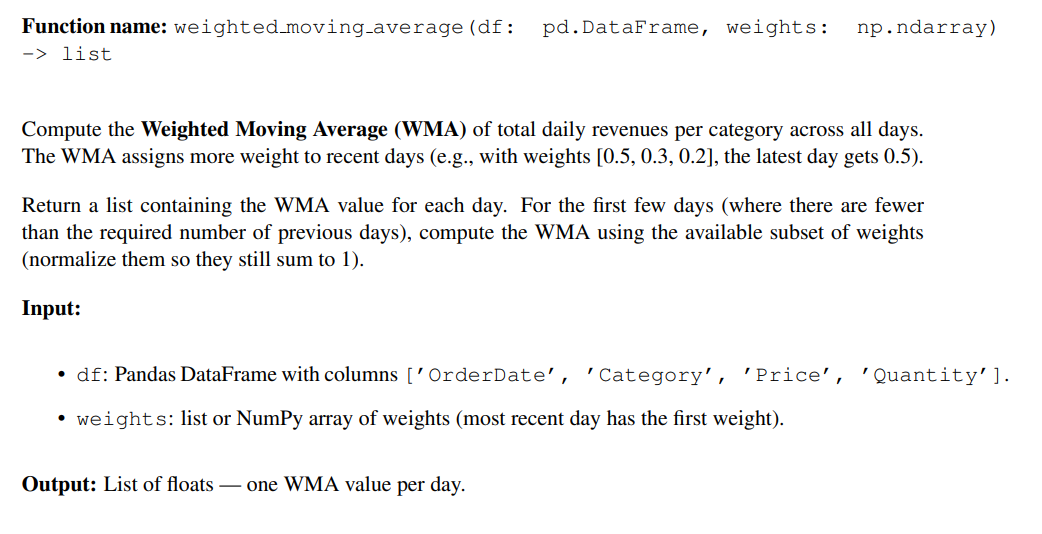

In [113]:
import pandas as pd

def weighted_moving_average(df: pd.DataFrame, weights: list) -> list:
    '''
    Compute weighted moving average of total daily revenues (Price * Quantity)
    with more weight assigned to recent days.
    '''
    df['Revenue'] = df['Price']*df['Quantity']
    daily_revenue_series = df.groupby('OrderDate')['Revenue'].sum().sort_index()
    print(daily_revenue_series)

    print(daily_revenue_series.values)
    #df = df.sort_values(by='OrderDate', ascending=False)

    weights = weights[::-1]
    # print(weights)
    wma = []
    revenue: np.float64 = None
    for index, row in df.iterrows():
        # print(index, ":", row['Revenue'])
        if not revenue:
            revenue = float(row['Revenue'])
            wma.append(revenue) # As first day gets full weight
            revenue = float(revenue * weights[index])
        else:
            revenue = float(revenue+float(row['Revenue']*weights[index]))
            wma.append(revenue)
            
    #print(df)

    return wma

def round_list(l, n):
    return [round(x, n) for x in l]

data1 = {'OrderDate':['2025-10-01'],'Price':[100],'Quantity':[1],'Category':['Electronics']}
df1 = pd.DataFrame(data1)
df1['OrderDate'] = pd.to_datetime(df1['OrderDate'])
print(round_list(weighted_moving_average(df1,[0.4,0.35,0.25]),3))
data2 = {'OrderDate':['2025-10-01','2025-10-02'],'Price':[50,70],'Quantity':[2,3],'Category':['A','A']}
df2 = pd.DataFrame(data2)
df2['OrderDate'] = pd.to_datetime(df2['OrderDate'])
print(round_list(weighted_moving_average(df2,[0.6,0.4]),3))

OrderDate
2025-10-01    100
Name: Revenue, dtype: int64
[100]
[100.0]
OrderDate
2025-10-01    100
2025-10-02    210
Name: Revenue, dtype: int64
[100 210]
[100.0, 166.0]


In [109]:
import pandas as pd
import numpy as np

def weighted_moving_average(df: pd.DataFrame, weights: np.ndarray) -> list:
    """
    Computes the Weighted Moving Average (WMA) of total daily revenues per category 
    across all days. The WMA assigns more weight to recent days.

    The WMA is calculated on the *total daily revenue* aggregated across all categories.

    Args:
        df (pd.DataFrame): Pandas DataFrame with columns ['OrderDate', 'Category', 'Price', 'Quantity'].
        weights (np.ndarray): NumPy array of weights (most recent day has the first/highest weight).

    Returns:
        list: A list of floats, one WMA value per day.
    """
    # 1. Prepare the data: Calculate daily total revenue
    df['Revenue'] = df['Price'] * df['Quantity']
    
    # Group by OrderDate and sum the revenue to get total daily revenue (across all categories)
    daily_revenue_series = df.groupby('OrderDate')['Revenue'].sum().sort_index()
    
    # Convert the weights to a numpy array if it's not already, and ensure it's float
    weights = np.array(weights, dtype=float)
    N = len(weights)
    
    # Convert daily revenue to a numpy array for easier window calculations
    revenue_values = daily_revenue_series.values
    M = len(revenue_values)
    wma_results = []

    # 2. Calculate WMA for each day
    for i in range(M):
        # The window of values to consider are the current day and the preceding N-1 days.
        # This slice goes up to and includes the current day (i+1) 
        # and back up to N elements (i - N + 1).
        
        # Determine the start index of the window
        start_index = max(0, i - N + 1)
        
        # Get the daily revenue values for the current window (most recent last)
        window_values = revenue_values[start_index : i + 1]
        
        # Determine the number of available days in the current window
        K = len(window_values)
        
        # The weights correspond to the K most recent days.
        # Since the weights array is ordered [w_recent, w_less_recent, ...], 
        # we take the first K weights.
        subset_weights = weights[:K]
        
        # 3. Normalize the weights if the subset is smaller than the full weights array
        if K < N:
            # Normalize the available subset of weights so they sum to 1
            subset_weights = subset_weights / subset_weights.sum()
        
        # 4. Calculate the WMA
        # The window_values are ordered chronologically (oldest first).
        # The subset_weights are ordered from most recent to oldest.
        # We need to reverse the window_values so that the newest value (last in window) 
        # is multiplied by the newest weight (first in subset_weights).
        
        # Note: If window_values are [rev_old, ..., rev_new] and subset_weights are [w_new, ..., w_old],
        # we need the dot product of [rev_new, ..., rev_old] and [w_new, ..., w_old].
        # We can achieve this by multiplying the chronologically ordered values 
        # with the *reversed* subset_weights.
        # Example: rev_old * w_old + ... + rev_new * w_new
        
        # We reverse the weights: [w_new, ..., w_old] -> [w_old, ..., w_new]
        reversed_weights = subset_weights[::-1]

        # Calculate WMA: dot product of (chronological values) * (reversed weights)
        wma = np.dot(window_values, reversed_weights)
        
        wma_results.append(wma)

    return wma_results

def round_list(l, n):
    return [round(x, n) for x in l]

data1 = {'OrderDate':['2025-10-01'],'Price':[100],'Quantity':[1],'Category':['Electronics']}
df1 = pd.DataFrame(data1)
df1['OrderDate'] = pd.to_datetime(df1['OrderDate'])
print(round_list(weighted_moving_average(df1,[0.4,0.35,0.25]),3))
data2 = {'OrderDate':['2025-10-01','2025-10-02'],'Price':[50,70],'Quantity':[2,3],'Category':['A','A']}
df2 = pd.DataFrame(data2)
df2['OrderDate'] = pd.to_datetime(df2['OrderDate'])
print(round_list(weighted_moving_average(df2,[0.6,0.4]),3))

[np.float64(100.0)]
[np.float64(100.0), np.float64(166.0)]
